# NLP Feature Engineering

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as IMBPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from nltk.corpus import stopwords
import nltk
from typing import cast
from scipy.sparse import hstack, csr_matrix, spmatrix
import joblib

# Download standard list once
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
# Importing the labeled_reviews.csv file into a pandas DataFrame
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

df = pd.read_csv("../data/interim/labeled2_reviews.csv")

In [5]:
"""Reloading utils module to reflect recent changes without restarting the kernel"""
import importlib
from src import utils

importlib.reload(utils)
from src.utils import summarize_df

In [7]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count,age_group
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8,25-34
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62,25-34
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98,55-64
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22,45-54
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36,45-54


### Creating the Custom Stop Words list 

In [27]:
# Removing the poisining phrases
POISON_PHRASES: list[str] = [
    "true to size", "true size", "love dress", "love love",
    "fit perfectly", "fits perfectly", "fit great", "just right",
    "looks like", "looks great", "looked like", "look like", "look great",
    "highly recommend", "super cute", "absolutely love", "really wanted",
    "received compliments", "soft comfortable", "material soft", "fabric soft", "super soft",
    "usually wear", "normally wear", "usual size", "wait wear", "easy wear", "fit well", "fits well",
    "well made"
]

# Positive sentiments words to remove
INDIVIDUAL_STOP_WORDS: list[str] = [
    "love", "great", "perfect", "cute", "recommend", "compliments", "comfortable",
    "want", "wanted", "feel", "like", "nice", "good"
]

stop_words: set[str] = set(stopwords.words("english"))

negations: set[str] = {"no", "not", "nor", "neither", "never", "none"}

final_stop_words: list[str] = list(stop_words - negations)

# Add our domain-specific positive stop words
final_stop_words.extend(INDIVIDUAL_STOP_WORDS)

print(f"Stop words count: {len(final_stop_words)}")
print(f"'not' in stop_words? {'not' in final_stop_words}") # Should be False

Stop words count: 208
'not' in stop_words? False


### Designing the Cleaning Function

In [29]:
def clean_review_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove Poison Phrases from the text
    for phrase in POISON_PHRASES:
        # Replace with space
        text = re.sub(re.escape(phrase), "", text)


    words: list[str] = text.split()
    words_cleaned: list[str] = []
    
    for word in words:
        if (word not in final_stop_words) or (word in negations):
            words_cleaned.append(word)
    
    text = " ".join(words_cleaned)


    # Remove special chars but KEEP numbers
    # Keeping letters, numbers and basic punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Applying the cleaning function to the "review_text" column
df["clean_text"] = df["review_text"].apply(clean_review_text)

# Check the difference
print("Original:", df.iloc[0]["review_text"])
print("Cleaned:",  df.iloc[0]["clean_text"])

Original: Absolutely wonderful - silky and sexy and comfortable
Cleaned: absolutely wonderful silky sexy


In [10]:
display(df.head())

,index_id,clothing_id,age,review_text,rating,return_category,word_count,age_group,clean_text
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other,8,25-34,absolutely wonderful silky sexy
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other,62,25-34,dress sooo pretty happened find store glad bc ...
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect,98,55-64,high hopes dress work me initially ordered pet...
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other,22,45-54,love love jumpsuit fun flirty fabulous every t...
4,4,847,47,This shirt is very flattering to all due to th...,5,Other,36,45-54,shirt flattering due adjustable front tie leng...


### Verifying the Bi-Grams in the cleandd text

Visualizing Bigrams for Category: Defect


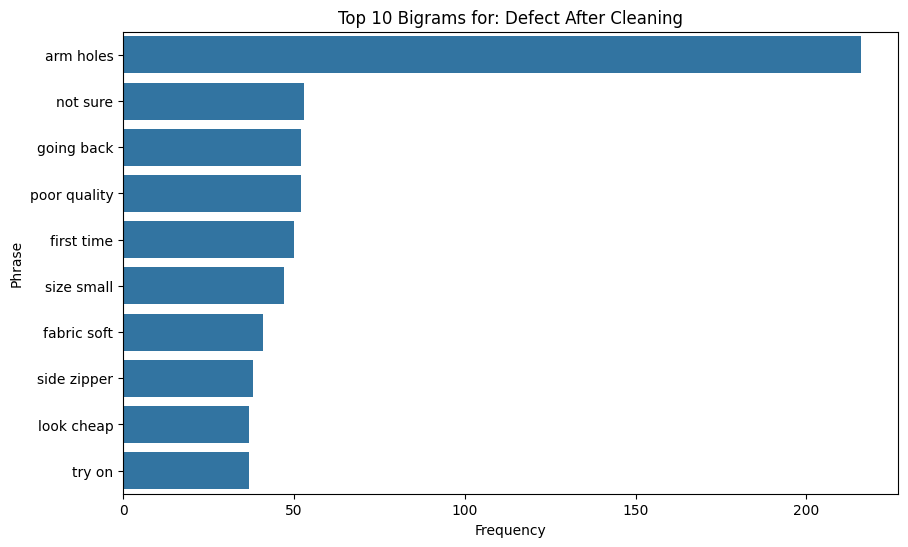

Visualizing Bigrams for Category: Sizing


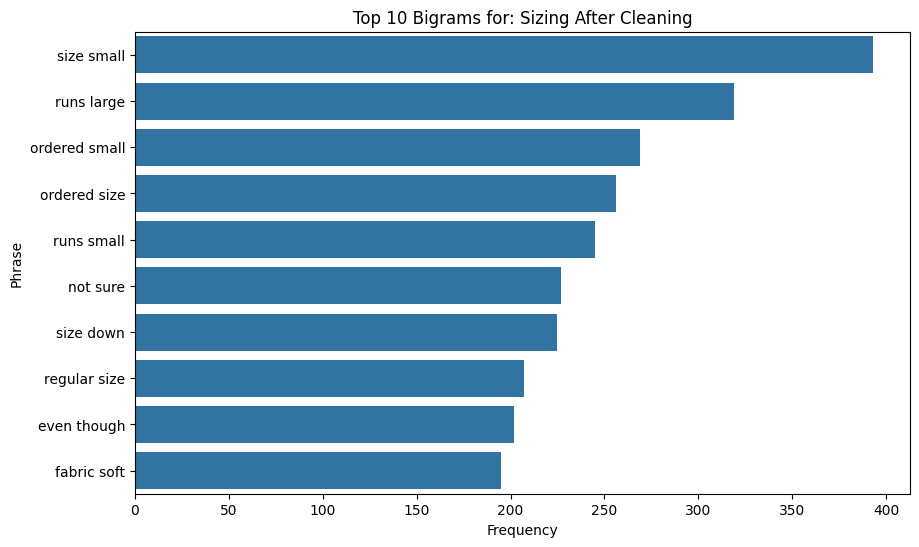

In [30]:
from src.utils import visualize_ngrams_clean as vng_c


cats = ["Defect", "Sizing"]
# cats = df["return_category"].unique().tolist()

for cat in cats:
    print(f"Visualizing Bigrams for Category: {cat}")
    vng_c(df, cat)

### Performing TF-IDF Vectorization

In [32]:
# Initializing our Vectorizer
# - ngram_range=(1,2): Capture unigrams ("broken") and bigrams ("zipper broke")
# - min_df=5: Ignore words that appear in less than 5 reviews (Typo filtering)
# - stop_words: Our custom list that KEEPS "not"

tfidf = TfidfVectorizer(
    ngram_range=(1, 2), # Capturing unigrams and bigrams
    max_features=5000, # Limits dimensionality to prevent overfitting
    stop_words=None, # We already cleaned the text in column "clean_text"
    min_df=5, # Ignoring very rare words
    max_df=.95 # Ignoring very common words
)

# Create the Feature Matrix for text data
print("Vectorizing the text data...")
X_text = tfidf.fit_transform(df["clean_text"])

print(f"Shape of Text Features: {X_text.shape}")
print(f"Feature Names Sample (First 20): {tfidf.get_feature_names_out()[:20]}")


# Quick sanity check: Print a few features from the middle to ensure bigrams exist
print(f"Feature Names sample (Middle): {tfidf.get_feature_names_out()[2500:2550]}")

Vectorizing the text data...
Shape of Text Features: (22641, 5000)
Feature Names Sample (First 20): ['00' '00p' '02' '0p' '10' '10 12' '100' '100 cotton' '1012' '105'
 '105 lbs' '108' '110' '110 lbs' '110lbs' '115' '115 lbs' '115lbs' '117'
 '118']
Feature Names sample (Middle): ['many people' 'many retailer' 'many things' 'many times' 'many tops'
 'many ways' 'mark' 'massive' 'match' 'matches' 'matching' 'material'
 'material also' 'material bit' 'material design' 'material dress'
 'material feels' 'material light' 'material little' 'material makes'
 'material nice' 'material not' 'material pretty' 'material quality'
 'material really' 'material soft' 'material thick' 'material thin'
 'material top' 'materials' 'maternity' 'maternity dress' 'maternity top'
 'matronly' 'matter' 'mauve' 'maxi' 'maxi dress' 'may' 'may look'
 'may need' 'may not' 'may run' 'may size' 'may try' 'may work' 'maybe'
 'maybe even' 'maybe little' 'maybe would']


In [33]:
df.dtypes

index_id            int64
clothing_id         int64
age                 int64
review_text        object
rating              int64
return_category    object
word_count          int64
age_group          object
clean_text         object
dtype: object

In [14]:


summarize_df(df)

===== DataFrame (DF) Summary =====
===== DataFrame Index =====


RangeIndex(start=0, stop=22641, step=1)

===== DataFrame Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22641 entries, 0 to 22640
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index_id         22641 non-null  int64 
 1   clothing_id      22641 non-null  int64 
 2   age              22641 non-null  int64 
 3   review_text      22641 non-null  object
 4   rating           22641 non-null  int64 
 5   return_category  22641 non-null  object
 6   word_count       22641 non-null  int64 
 7   age_group        22641 non-null  object
 8   clean_text       22641 non-null  object
dtypes: int64(5), object(4)
memory usage: 1.6+ MB

===== DataFrame Description =====


,index_id,clothing_id,age,review_text,rating,return_category,word_count,age_group,clean_text
count,22641.000000,22641.000000,22641.000000,22641,22641.000000,22641,22641.000000,22641,22641
unique,NaN,NaN,NaN,22634,NaN,4,NaN,7,22632
top,NaN,NaN,NaN,Perfect fit and i've gotten so many compliment...,NaN,Sizing,NaN,35-44,fit gotten many compliments buy suits now
freq,NaN,NaN,NaN,3,NaN,11980,NaN,7093,3
mean,11740.849035,919.332362,43.280376,NaN,4.183561,NaN,60.196679,NaN,NaN
std,6781.957509,202.266874,12.326980,NaN,1.115762,NaN,28.534612,NaN,NaN
min,0.000000,1.000000,18.000000,NaN,1.000000,NaN,2.000000,NaN,NaN
25%,5872.000000,861.000000,34.000000,NaN,4.000000,NaN,36.000000,NaN,NaN
50%,11733.000000,936.000000,41.000000,NaN,5.000000,NaN,59.000000,NaN,NaN
75%,17621.000000,1078.000000,52.000000,NaN,5.000000,NaN,88.000000,NaN,NaN



===== Duplicate Rows =====
No duplicate rows found.

===== Missing Values per Column =====
index_id           0
clothing_id        0
age                0
review_text        0
rating             0
return_category    0
word_count         0
age_group          0
clean_text         0
dtype: int64


### Training and Evaluating Multiple Classification Models

In [15]:
class ScaleNumericSparse:
    """
    Custom scaler that scales only the last N columns (numeric features)
    while preserving the sparse matrix structure for text features.
    Text features are been passed first and numerical features are passed
    at the end of the sparse matrix. 
    e.g ScalerNumericSparse(3) will scale the last 3 columns and leave the first columns (text features) unchanged.
    X = [text_features + numerical_features]
    """
    def __init__(self, n_numerical_feature=3):
        """Based on MaxAbsScaler to scale data to [-1,1]"""
        self.n_numerical_feature = n_numerical_feature
        self.scaler = MaxAbsScaler() # Works on sparse matrices
    
    def fit(self, X, y=None):
        """Fitting the scaler on the numeric features"""
        n_text_features: int = X.shape[1] - self.n_numerical_feature
        numerical_features = X[:, n_text_features:] # Still sparse

        # Fitting the scaler 
        self.scaler.fit(numerical_features)
        self.n_text_features_ = n_text_features
        return self
    
    def transform(self, X):
        """Transformming the numerical featuers"""
        text_features = X[:, :self.n_text_features_]
        numerical_features = X[:, self.n_text_features_:]

        # Scaling the numeric features while maintaininng sparsity
        numerical_scaled = self.scaler.transform(numerical_features)

        # Recombine everything 
        return hstack([text_features, numerical_scaled], dtype=np.float32)
    
    def fit_transform(self, X, y=None):
        """Fitting and Transforming at once"""
        return self.fit(X, y).transform(X)
    
# scaler = ScaleNumericSparse(n_numerical_feature=3)

In [34]:
type(X_text)

scipy.sparse._csr.csr_matrix

In [17]:
numeric_features = df[["age", "rating", "word_count"]] # Trying sth different

# Then combine Feature
X = cast(spmatrix, hstack([csr_matrix(numeric_features), X_text], dtype=np.float32))

# Indices used by ColumnTransformer
num_indices: list[int] = [0, 1, 2]
text_indices: list[int] = list(range(3, X.shape[1]))

preprocessor = ColumnTransformer(
    transformers=[
        ("numeic_features", MaxAbsScaler(), num_indices),
        ("text_feature", MaxAbsScaler(), text_indices)
    ], 
    remainder="drop",
    sparse_threshold=0.3 # If th combined features are more than 30% sparse, it will return a sparse matrix, otherwise a dense one.
)

# Target 
le = LabelEncoder()
y = le.fit_transform(df["return_category"])

In [18]:
label_mapping = {
    cls: i for i, cls in enumerate(le.classes_)
}
print(label_mapping)

{'Defect': 0, 'Other': 1, 'Sizing': 2, 'Style': 3}


In [19]:
"""Inversing classes"""
le.inverse_transform([0, 2])

array(['Defect', 'Sizing'], dtype=object)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, shuffle=True, stratify=y, random_state=42
)

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Dict of all pipelines
pipelines: dict = { 
    "LogisticRegression": IMBPipeline(steps=[
        ("processor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("ovr_lr", OneVsRestClassifier(LogisticRegression(max_iter=5000, random_state=42, tol=1e-3, solver="lbfgs")))
    ]), 
    # Adding scaler to Tree-model to ensure synthetic data generation is of high quality
    "RandomForestClassifier": IMBPipeline(steps=[
        ("processor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("rfc", RandomForestClassifier(random_state=42, verbose=1, n_jobs=1))
    ]),
    "XGBClassifier": IMBPipeline(steps=[
        ("processor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("xgbc", XGBClassifier(objective="multi:softprob", random_state=42, tree_method="hist", n_estimators=200, n_jobs=1))
    ]),
    "LGBMClassifier": IMBPipeline(steps=[
        ("processor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("lgbmc", LGBMClassifier(objective="multiclass", random_state=42, verbosity=-1, n_estimators=200, importance_type="gain", n_jobs=1))
    ])
}

# Hyperparameter grids for each model
param_grid: dict = {
    "RandomForestClassifier": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
    }, 
    "XGBClassifier": {
        "max_depth": [4, 6],
        "learning_rate": [0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "LGBMClassifier": {
        "max_depth": [4, 6],
        "subsample": [0.8, 1.0],
        "min_child_samples": [5, 10, 20], # Helps find splits in sparse data
        "learning_rate": [0.05, 0.1],
        "colsample_bytree": [0.8, 1.0]
    }
}

# CROSS VALIDATION SETUP
results: list = [] # Stores the CV_Scores for each model
estimators: dict = {}
cv_score: float = 0.0
best_score: float = 0.0

print(f"Starting Training loop on {len(pipelines)} models...")
print("-" * 50)

for name, pipeline in pipelines.items():
    print(f"Training (Fitting) {name}")

    search_params: dict = {}

    # To prevent UnboundError
    step_name: str = "" 
    grid_key: str | None = ""

    # Identifying which algorithm is running
    #  "LogisticRegression" in name: grid_key, step_name = "LogisticRegression", "lr"
    if "RandomForestClassifier" in name: grid_key, step_name = "RandomForestClassifier", "rfc"
    elif "XGBClassifier" in name: grid_key, step_name = "XGBClassifier", "xgbc"
    elif "LGBMClassifier" in name: grid_key, step_name = "LGBMClassifier", "lgbmc"
    else: grid_key = None # No hyperparameter tuning for Logistic Regression

    # Build the parameter grid for GridSearchCV
    if (grid_key) and (grid_key in param_grid): 
        for param, values in param_grid[grid_key].items():
            search_params[f"{step_name}__{param}"] = values

    # Default to untrained pipeline to silent Pylance warning
    final_model = pipeline 
    best_score: float = 0.0
    best_params: dict | str = {}

    # Run GridSearchCV if the model is in the param_grid
    if search_params:
        model = GridSearchCV(
            pipeline, 
            param_grid=search_params,
            cv=kf,
            scoring="f1_macro",
            n_jobs=-1,
            verbose=1,
            error_score="raise"
        )

        """Fitting the model on the entire training data"""
        model.fit(X_train, y_train)
        final_model = model.best_estimator_ # Best pipeline with best hyperparameters
        best_score = round(model.best_score_, 4)
        best_params = model.best_params_

        # Saving teh CV results for analysis
        cv_results = pd.DataFrame(model.cv_results_)
        sorted_results = cv_results[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False)
        display(sorted_results)

    else: # If the model was not in the param_grid, fit the pipeline directly (OVR Logistic Regression)
        cv_scores: np.ndarray = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=kf,
            scoring="f1_macro"
        )
    
        cv_score = round(cv_scores.mean(), 4) # AVG FA_MACRO
        best_params = "Default"

        # Fitting the model on the entire training data
        pipeline.fit(X_train, y_train) 
        final_model = pipeline

    # Store results
    results.append({
        "Model": name,
        "CV_F1_MACRO": best_score if search_params else cv_score,
        "Best Params": best_params
    })

    # Saving the model object
    estimators[name] = final_model
    print(f"Completed training for {name}. CV_F1_MACRO: {results[-1]["CV_F1_MACRO"]:.4f}")


# LEADERBOARD
print("-" * 50)
print("Printing the Model Leaderboard sorted by CV_F1_MACRO:")
leaderb_df = pd.DataFrame(results).sort_values("CV_F1_MACRO", ascending=False)
display(leaderb_df)

# SAVING LEADERBOARD AS A CSV FILE
print("Saving leaderboard dataframe as a csv file...")
output_path = "../data/processed/leaderb.csv"
leaderb_df.to_csv(output_path, index=False) 
print(f"Data successfully saved to {output_path}")

# SAVING MODELS
print("Saving models and encoder to disk...")
joblib.dump((estimators, le), "../src/estimators.pkl")
print("Done.")

Starting Training loop on 4 models...
--------------------------------------------------
Training (Fitting) LogisticRegression
Completed training for LogisticRegression. CV_F1_MACRO: 0.8197
Training (Fitting) RandomForestClassifier
Fitting 3 folds for each of 4 candidates, totalling 12 fits


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   13.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   37.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   37.4s finished


,params,mean_test_score,std_test_score
3,"{'rfc__max_depth': 20, 'rfc__n_estimators': 200}",0.727942,0.018718
2,"{'rfc__max_depth': 20, 'rfc__n_estimators': 100}",0.720252,0.012610
1,"{'rfc__max_depth': 10, 'rfc__n_estimators': 200}",0.684773,0.012413
0,"{'rfc__max_depth': 10, 'rfc__n_estimators': 100}",0.669098,0.010976


Completed training for RandomForestClassifier. CV_F1_MACRO: 0.7279
Training (Fitting) XGBClassifier
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,params,mean_test_score,std_test_score
3,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin...",0.922676,0.003545
7,"{'xgbc__colsample_bytree': 1.0, 'xgbc__learnin...",0.922127,0.003194
2,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin...",0.921298,0.003354
6,"{'xgbc__colsample_bytree': 1.0, 'xgbc__learnin...",0.920357,0.002846
5,"{'xgbc__colsample_bytree': 1.0, 'xgbc__learnin...",0.914038,0.002845
1,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin...",0.913686,0.002521
4,"{'xgbc__colsample_bytree': 1.0, 'xgbc__learnin...",0.912895,0.002356
0,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin...",0.912499,0.002894


Completed training for XGBClassifier. CV_F1_MACRO: 0.9227
Training (Fitting) LGBMClassifier
Fitting 3 folds for each of 48 candidates, totalling 144 fits


,params,mean_test_score,std_test_score
20,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.926867,0.003961
21,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.926867,0.003961
22,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.926767,0.004049
23,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.926767,0.004049
47,"{'lgbmc__colsample_bytree': 1.0, 'lgbmc__learn...",0.926496,0.004003
46,"{'lgbmc__colsample_bytree': 1.0, 'lgbmc__learn...",0.926496,0.004003
45,"{'lgbmc__colsample_bytree': 1.0, 'lgbmc__learn...",0.926268,0.003859
44,"{'lgbmc__colsample_bytree': 1.0, 'lgbmc__learn...",0.926268,0.003859
19,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.925852,0.003476
18,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn...",0.925852,0.003476


Completed training for LGBMClassifier. CV_F1_MACRO: 0.9269
--------------------------------------------------
Printing the Model Leaderboard sorted by CV_F1_MACRO:


,Model,CV_F1_MACRO,Best Params
3,LGBMClassifier,0.9269,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn..."
2,XGBClassifier,0.9227,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin..."
0,LogisticRegression,0.8197,Default
1,RandomForestClassifier,0.7279,"{'rfc__max_depth': 20, 'rfc__n_estimators': 200}"


Saving leaderboard dataframe as a csv file...
Data successfully saved to ../data/processed/leaderb.csv
Saving models and encoder to disk...
Done.


### Predicting and Calculating Evaluation Metrics (Classification Report and Confusion Matrix)

In [21]:
"""Ignoring harmless warnings from LightGBM
- During fitting, although LightGBM fitted on a naked sparse matrix (X_train), ColumnTransformer
    generated internal feature names based on the step names we provided ["numeric_features", "text_feature"].
    CT passed these generated names (e.g., numeic_features__x0, text_feature__x3) to the LightGBM model.
    LightGBM "memorizes" these names.
- During prediction, when we call xgbc_model.predict(X_test) and pass X_test (also a naked sparse matrix), LightGBM notices that 
    the sparse matrix had no feature names. LightGBM looks at the matrix and says: "Hey, during training I had names for these 
    columns, but now you're giving me a matrix with no names. I'll still do the math, but I'm just letting you know there's a mismatch."

Is it a Problem? 
No. As long as the order of our columns in X_test is the same as X_train (which it is, because they came from the same hstack operation), 
the predictions are 100% accurate. We can safely ignore it.
"""
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

#### Loading the saved Leaderboard 

In [6]:
# Importing the leaderb.csv file into a pandas DataFrame
leaderb_df = pd.read_csv("../data/processed/leaderb.csv").sort_values("CV_F1_MACRO", ascending=False)
display(leaderb_df)

,Model,CV_F1_MACRO,Best Params
0,LGBMClassifier,0.9269,"{'lgbmc__colsample_bytree': 0.8, 'lgbmc__learn..."
1,XGBClassifier,0.9227,"{'xgbc__colsample_bytree': 0.8, 'xgbc__learnin..."
2,LogisticRegression,0.8197,Default
3,RandomForestClassifier,0.7279,"{'rfc__max_depth': 20, 'rfc__n_estimators': 200}"


In [10]:
from sklearn.metrics import classification_report
import joblib

# 1. Retrieving estimators dictionary
print("Loading models and encoder from disk...")
# Note: Ensure the path is correct relative to your notebook location
estimators, le = joblib.load("../src/estimators.pkl")

# 2. Extract Models
xgbc_model = estimators["XGBClassifier"]
lgbmc_model = estimators["LGBMClassifier"]

# 3. Retrieve CV F1_MACRO from your leaderboard dataframe
# Renamed variables to f1 for accuracy (RMSE is for regression)
xgb_cv_f1 = leaderb_df.loc[
    leaderb_df["Model"] == "XGBClassifier", "CV_F1_MACRO"
].values[0]

lgbm_cv_f1 = leaderb_df.loc[
    leaderb_df["Model"] == "LGBMClassifier", "CV_F1_MACRO"
].values[0]

print(f"XGBoost CV F1: {xgb_cv_f1}")
print(f"LGBM CV F1: {lgbm_cv_f1}")
print("-" * 30)

# 4. Generate Predictions
xgbc_pred = xgbc_model.predict(X_test)
lgbmc_pred = lgbmc_model.predict(X_test)

# 5. Classification report of XGBoost
print("XGBClassifier Classification Report:")
print(classification_report(y_test, xgbc_pred, target_names=le.classes_))

print("\n" + "="*50 + "\n")

# 6. Classification report of LightGBM
print("LGBMClassifier Classification Report:")
print(classification_report(y_test, lgbmc_pred, target_names=le.classes_))

Loading models and encoder from disk...


KeyError: 'LGBMClassifier'

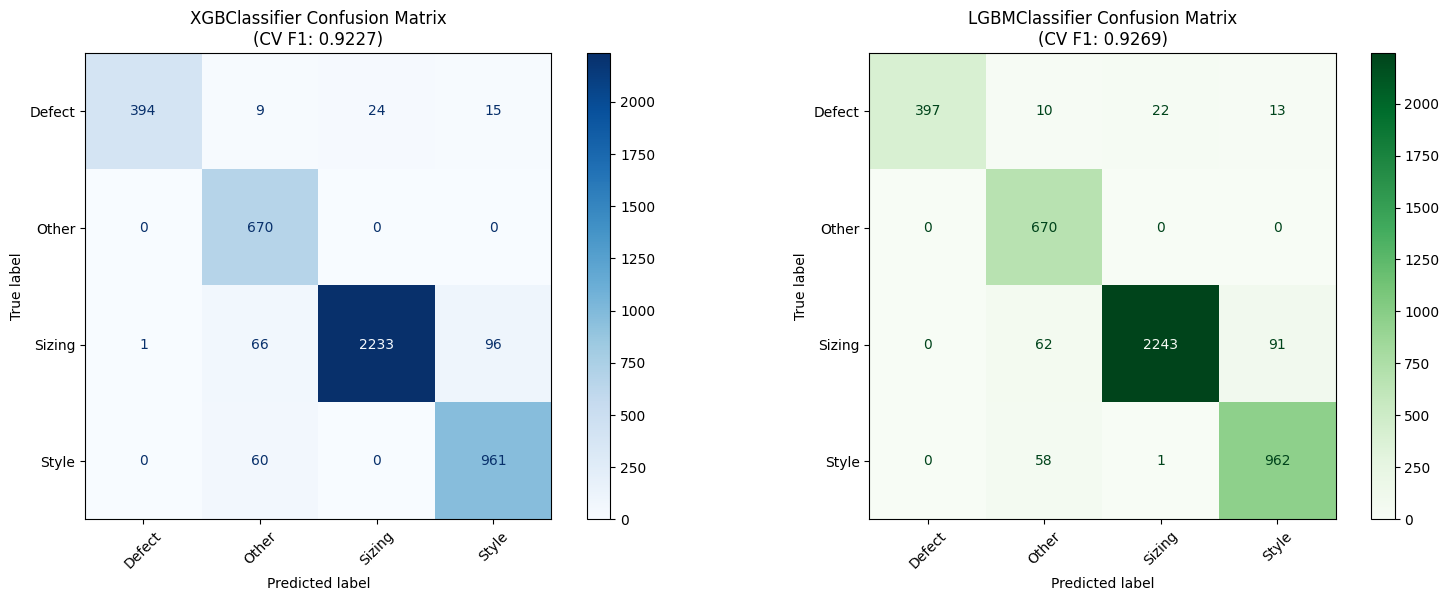

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Setup the figure for two plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- XGBoost Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    xgbc_pred, 
    display_labels=le.classes_, 
    cmap='Blues', 
    ax=ax1,
    xticks_rotation=45
)
ax1.set_title(f"XGBClassifier Confusion Matrix\n(CV F1: {xgb_cv_f1})")

# --- LightGBM Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    lgbmc_pred, 
    display_labels=le.classes_, 
    cmap='Greens', 
    ax=ax2,
    xticks_rotation=45
)
ax2.set_title(f"LGBMClassifier Confusion Matrix\n(CV F1: {lgbm_cv_f1})")

plt.tight_layout()
plt.show()

### PnL (Profit and Loss) Simulation and Evaluation Metrics

In [ ]:
# --- PnL SIMULATION: The "ReturnX Logistics" Strategy ---

# 1. Setup the Simulation Data
# We use the results from our XGBClassifier
best_model= estimators["XGBClassifier"]
y_pred = best_model.predict(X_test)

df_pnl = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

# Map integers back to strings for clarity
label_mapping = {i: cls for i, cls in enumerate(le.classes_)}
df_pnl["actual_label"] = df_pnl["actual"].map(label_mapping)
df_pnl["pred_label"] = df_pnl["predicted"].map(label_mapping)

# 2. Define Business Costs
COST_MANUAL: float = 2.00 # Cost if a human does everything
COST_AUTO: float = 0.10 # Cost if model is correct
COST_PENALTY: float = 5.00 # Cost if model is wrong (Correction cost)

# 3. Define the Simulation Logic
def calculate_pnl(row):
    # Scenario A: Business as Usual (BAU)
    # Every single item is reviewed by a human
    cost_bau = COST_MANUAL

    # Scenario B: ReturnX AI Strategy
    if row["actual"] == row["predicted"]:
        cost_model = COST_AUTO
    else:
        # Model was wrong! We paid for the auto-check AND a high correction penalty
        cost_model = COST_AUTO + COST_PENALTY
        
    return pd.Series([cost_bau, cost_model], index=["Cost_BAU", "Cost_Model"])

# 4. Run the Simulation
pnl_results: pd.DataFrame = df_pnl.apply(calculate_pnl, axis=1) # Row-wise (One row as Series)

# 5. Aggregate Results
total_bau_cost = pnl_results["Cost_BAU"].sum()
total_model_cost = pnl_results["Cost_Model"].sum()
total_savings = total_bau_cost - total_model_cost
roi = (total_savings / total_model_cost) * 100

print("-" * 50)
print("RETURN-X: INTELLIGENT ROUTING PnL SIMULATION")
print("-" * 50)
print(f"Total Returns Processed:          {len(df_pnl):,}")
print(f"Operational Cost (Manual/BAU):    ${total_bau_cost:,.2f}")
print(f"Operational Cost (ReturnX AI):    ${total_model_cost:,.2f}")
print("-" * 50)
print(f"TOTAL COST SAVINGS:               ${total_savings:,.2f}")
print(f"Return on AI Investment (ROI):     {roi:.1f}%")
print("-" * 50)

# Break down by class to see where the money is made
df_pnl["Savings"] = pnl_results["Cost_BAU"] - pnl_results["Cost_Model"]
class_savings = df_pnl.groupby("actual_label")["Savings"].sum().sort_values(ascending=False).round(2)

print("\nSAVINGS BY RETURN CATEGORY:")
display(class_savings)

NameError: name 'estimators' is not defined

In [1]:
display(df_pnl)

NameError: name 'df_pnl' is not defined